# Plot for the Binary system of 30 Solar mass and 25 Solar mass

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
from pathlib import Path
import pandas as pd

In [2]:
path = "/home/poornima/Documents/BSE_METISSE_project/output_binary/"
file_name = "03000M_02500M.dat"
full_path = os.path.join(path, file_name)

data = np.loadtxt(full_path) 


In [3]:
x_max = 30

e = 0.4
p = 15
Z = 0.02

In [4]:
base_name = Path(file_name).stem

In [5]:
num_cols = data.shape[1]  # number of columns
print("Number of columns:", num_cols)

num_cols = data.shape[0]  # number of rows
print("Number of Rows:", num_cols)

Number of columns: 23
Number of Rows: 4387


In [6]:
# Define the column names
columns = [
    "Time",
    "stellar_type_1","stellar_type_2","initial_mass_1","initial_mass_2", "current_mass_1","current_mass_2","log10_r_1","log10_r_2",
    "ratio_of_rad_to_rl_rad_1","ratio_of_rad_to_rl_rad_2","log10_L_1","log10_L_2",
    "spin_1","spin_2","mass_loss_rate_1","mass_loss_rate_2","convective_envelope_mass_1","convective_envelope_mass_2",
    "envelope_radius_1","envelope_radius_2","sep","ecc"]
    
df = pd.DataFrame(data, columns=columns)

df.head()

,Time,stellar_type_1,stellar_type_2,initial_mass_1,initial_mass_2,current_mass_1,current_mass_2,log10_r_1,log10_r_2,ratio_of_rad_to_rl_rad_1,...,spin_1,spin_2,mass_loss_rate_1,mass_loss_rate_2,convective_envelope_mass_1,convective_envelope_mass_2,envelope_radius_1,envelope_radius_2,sep,ecc
0,0.000,1.0,1.0,30.0000,25.0000,0.0,0.0,0.8561,0.8141,0.5465,...,1251.0,1417.0,0.000000e+00,0.000000e+00,6.526000e-10,4.539000e-10,0.004031,0.003401,33.28,0.0
1,0.006,1.0,1.0,29.9987,24.9995,0.0,0.0,0.8566,0.8144,0.5463,...,1218.0,1387.0,-2.156000e-07,-8.227000e-08,6.553000e-10,4.581000e-10,0.004027,0.003424,33.32,0.0
2,0.012,1.0,1.0,29.9973,24.9989,0.0,0.0,0.8570,0.8147,0.5462,...,1186.0,1359.0,-2.282000e-07,-9.906000e-08,6.580000e-10,4.622000e-10,0.004022,0.003448,33.36,0.0
3,0.018,1.0,1.0,29.9960,24.9984,0.0,0.0,0.8575,0.8150,0.5461,...,1157.0,1332.0,-2.156000e-07,-8.228000e-08,6.607000e-10,4.663000e-10,0.004017,0.003472,33.40,0.0
4,0.024,1.0,1.0,29.9948,24.9979,0.0,0.0,0.8579,0.8153,0.5461,...,1129.0,1306.0,-2.156000e-07,-8.228000e-08,6.634000e-10,4.705000e-10,0.004013,0.003495,33.44,0.0


In [7]:
# Compute log10Teff as a new column
df["log10Teff_1"] = 3 + 0.25 * (np.log10(1130) + df["log10_L_1"] - 2 * df["log10_r_1"])


df["log10Teff_2"] = 3 + 0.25 * (np.log10(1130) + df["log10_L_2"] - 2 * df["log10_r_2"])

In [8]:
df.head()

,Time,stellar_type_1,stellar_type_2,initial_mass_1,initial_mass_2,current_mass_1,current_mass_2,log10_r_1,log10_r_2,ratio_of_rad_to_rl_rad_1,...,mass_loss_rate_1,mass_loss_rate_2,convective_envelope_mass_1,convective_envelope_mass_2,envelope_radius_1,envelope_radius_2,sep,ecc,log10Teff_1,log10Teff_2
0,0.000,1.0,1.0,30.0000,25.0000,0.0,0.0,0.8561,0.8141,0.5465,...,0.000000e+00,0.000000e+00,6.526000e-10,4.539000e-10,0.004031,0.003401,33.28,0.0,4.607570,4.580520
1,0.006,1.0,1.0,29.9987,24.9995,0.0,0.0,0.8566,0.8144,0.5463,...,-2.156000e-07,-8.227000e-08,6.553000e-10,4.581000e-10,0.004027,0.003424,33.32,0.0,4.607395,4.580420
2,0.012,1.0,1.0,29.9973,24.9989,0.0,0.0,0.8570,0.8147,0.5462,...,-2.282000e-07,-9.906000e-08,6.580000e-10,4.622000e-10,0.004022,0.003448,33.36,0.0,4.607245,4.580345
3,0.018,1.0,1.0,29.9960,24.9984,0.0,0.0,0.8575,0.8150,0.5461,...,-2.156000e-07,-8.228000e-08,6.607000e-10,4.663000e-10,0.004017,0.003472,33.40,0.0,4.607045,4.580245
4,0.024,1.0,1.0,29.9948,24.9979,0.0,0.0,0.8579,0.8153,0.5461,...,-2.156000e-07,-8.228000e-08,6.634000e-10,4.705000e-10,0.004013,0.003495,33.44,0.0,4.606895,4.580145


In [9]:
kstar_translator = [
    {'long': 'Main Sequence (Low mass)', 'short': 'MS < 0.7', 'colour':(0.6, 1.0, 0.0, 1.0) }, ##(0.996078, 0.843476, 0.469158, 1.0)
    {'long': 'Main Sequence', 'short': 'MS', 'colour': (0.996078, 0.843476, 0.469158, 1.0)},
    {'long': 'Hertzsprung Gap', 'short': 'HG', 'colour':(0.939608, 0.471373, 0.094902, 1.0) },  ##
    {'long': 'First Giant Branch', 'short': 'FGB', 'colour': (0.0, 0.9, 0.9, 1.0)},  ##(0.716186, 0.833203, 0.916155, 1.0)
    {'long': 'Core Helium Burning', 'short': 'CHeB', 'colour': (0.29098, 0.59451, 0.78902, 1.0)},
    {'long': 'Early AGB', 'short': 'EAGB', 'colour': (0.294902, 0.690196, 0.384314, 1.0)},
    {'long': 'Thermally Pulsing AGB', 'short': 'TPAGB',
     'colour': (0.723122, 0.889612, 0.697178, 1.0)},
    {'long': 'Helium Main Sequence', 'short': 'HeMS', 'colour': (0.254627, 0.013882, 0.615419, 1.0)},
    {'long': 'Helium Hertsprung Gap', 'short': 'HeHG', 'colour': (0.562738, 0.051545, 0.641509, 1.0)},
    {'long': 'Helium Giant Branch', 'short': 'HeGB', 'colour': (0.798216, 0.280197, 0.469538, 1.0)},
    {'long': 'Helium White Dwarf', 'short': 'HeWD', 'colour': (0.368166, 0.232828, 0.148275, 1.0)},
    {'long': 'Carbon/Oxygen White Dwarf', 'short': 'COWD', 'colour': (0.620069, 0.392132, 0.249725, 1.0)},
    {'long': 'Oxygen/Neon White Dwarf', 'short': 'ONeWD', 'colour': (0.867128, 0.548372, 0.349225, 1.0)},
    {'long': 'Neutron Star', 'short': 'NS', 'colour': (0.501961, 0.501961, 0.501961, 1.0)},
    {'long': 'Black Hole', 'short': 'BH', 'colour': 'black'},
    {'long': 'Massless Remnant', 'short': 'MR', 'colour': (1.0, 1.0, 0.0, 1.0)}
    
]

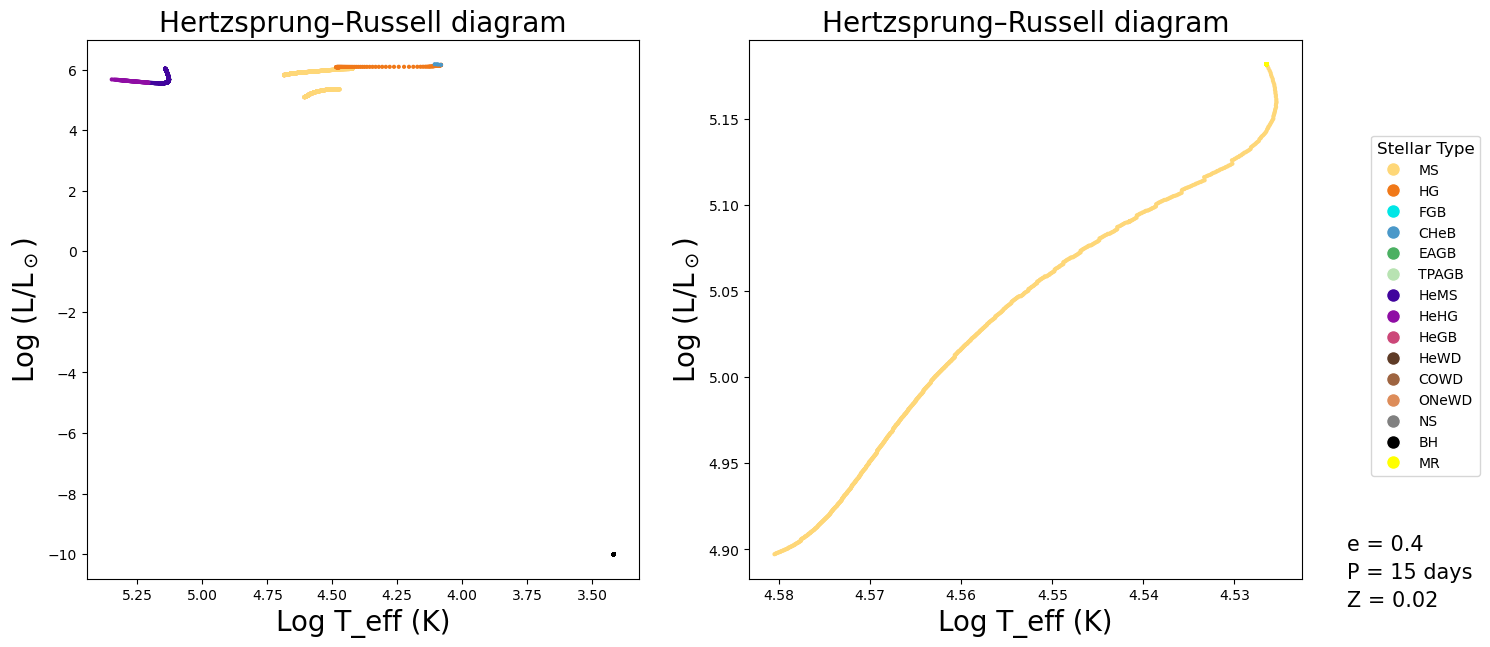

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
ax1, ax2 = axes  # primary = left, secondary = right

# ----------------------------
# Primary star (R1/ROL1)
# ----------------------------
ax1.scatter(
    df["log10Teff_1"], 
    df["log10_L_1"], 
    c=[kstar_translator[int(k)]["colour"] if 0 <= k < len(kstar_translator) else (0,0,0,1)
       for k in df["stellar_type_1"]], 
    s=4
)
# ax1.set_xlim(xmin=0.0, xmax=x_max)
# ax1.set_ylim(ymin=0.0, ymax=1)
#ax1.plot(df["log10Teff_1"], df["log10_L_1"], lw=0.5, color='black', linestyle='--', zorder=-1)
ax1.set_xlabel('Log T_eff (K)',fontsize=20)
ax1.set_ylabel(r'Log (L/L$_\odot$)', fontsize=20)
ax1.invert_xaxis()
ax1.set_title('Hertzsprung–Russell diagram',fontsize=20)

# ----------------------------
# Secondary star (R2/ROL2)
# ----------------------------
ax2.scatter(
    df["log10Teff_2"], 
    df["log10_L_2"], 
    c=[kstar_translator[int(k)]["colour"] if 0 <= k < len(kstar_translator) else (0,0,0,1)
       for k in df["stellar_type_2"]], 
    s=4
)
#ax2.set_xlim(xmin=0.0, xmax=x_max)
#ax2.plot(df["log10Teff_2"], df["log10_L_2"], lw=0.5, color='black',linestyle='--', zorder=-1)
ax2.set_xlabel('Log T_eff (K)',fontsize=20)
ax2.set_ylabel(r'Log (L/L$_\odot$)', fontsize=20)
ax2.invert_xaxis()
ax2.set_title('Hertzsprung–Russell diagram',fontsize=20)

# ----------------------------
# Common legend for stellar types
# ----------------------------
handles = []
labels = []
for kstar in range(1, 16):
    handles.append(plt.Line2D([0], [0], marker='o', color='w', 
                              markerfacecolor=kstar_translator[kstar]["colour"], markersize=10))
    labels.append(kstar_translator[kstar]["short"])

fig.legend(
    handles, labels,
    title='Stellar Type',
    fontsize=10,
    title_fontsize=12,
    loc='center right',
    bbox_to_anchor=(0.9, 0.5),
    borderaxespad=0.1
)

y0 = 0.15
dy = 0.04

fig.text(0.825, y0, f'e = {e}', fontsize=15)
fig.text(0.825, y0 - dy, f'P = {p} days', fontsize=15)
fig.text(0.825, y0-2*dy, f'Z = {Z}', fontsize=15)

fig.subplots_adjust(right=0.8)  # leave space for legend
plt.show()

img_title = "HR_diag"


save_name = f"{base_name}_{img_title}.png"

fig.savefig(save_name, dpi=300, bbox_inches="tight")